# COMP683 — Tabula Muris: Rare Cell Preservation Analysis

**Evaluating the Preservation of Rare Cell Populations Across FACS and Droplet Technologies**

This notebook implements the full analysis pipeline end-to-end:

1. Load and merge droplet and FACS expression matrices
2. Standard Scanpy preprocessing (QC → normalize → log1p → HVG selection → scale → PCA)
3. Three clustering pipelines: **Baseline** (no correction), **Harmony**, **BBKNN**
4. Metrics: ARI, NMI, and rare-cell recovery rate across Leiden resolutions
5. UMAP visualizations colored by platform, tissue, and cell type
6. Case study: T cells and macrophages across tissues

## Imports

In [1]:
from __future__ import annotations

import io
import logging
import re
import warnings
import zipfile
from pathlib import Path
from typing import Dict, List, Sequence

import anndata as ad
import bbknn
import harmonypy as hm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from scipy.io import mmread
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='[%(asctime)s] %(message)s', datefmt='%H:%M:%S')

%matplotlib inline

/opt/anaconda3/envs/comp683/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

All tunable parameters are set here. Modify this cell to change the analysis.

In [2]:
DATA_DIR = Path('data')
OUT_DIR  = Path('outputs')

# Leiden resolutions to sweep (Experiment 2)
RESOLUTIONS     = [0.2, 0.5, 1.0, 1.5]
# Rare-cell thresholds in percent of cells per tissue
RARE_THRESHOLDS = [1.0, 2.0, 5.0]
# Resolution used for fixed-resolution UMAP and case-study plots
FIXED_RES       = 1.0
# Recovery: a cluster must be >=50% from a rare type to count as recovered
PURITY_CUTOFF   = 0.5

N_HVG       = 2000
N_PCS       = 50
N_NEIGHBORS = 15
MIN_GENES   = 200
MIN_CELLS   = 3
SEED        = 0

np.random.seed(SEED)

for subdir in ['figures', 'metrics', 'adata']:
    (OUT_DIR / subdir).mkdir(parents=True, exist_ok=True)

print('Output directories ready.')

Output directories ready.


## Data-Loading Helper Functions

These helpers handle reading MTX and CSV count files from the zip archives.

In [3]:
def _read_text_lines(zf: zipfile.ZipFile, path: str) -> List[str]:
    with zf.open(path) as h:
        return [line.decode('utf-8').strip() for line in h if line.strip()]


def _parse_droplet_folder(folder_name: str):
    match = re.match(r'^(.*)-(10X_.*)$', folder_name)
    if not match:
        raise ValueError(f'Unexpected droplet folder format: {folder_name}')
    return match.group(1), match.group(2)


def _load_single_droplet_folder(zf: zipfile.ZipFile, folder_name: str) -> ad.AnnData:
    base = f'droplet/{folder_name}'
    mtx  = mmread(io.BytesIO(zf.read(f'{base}/matrix.mtx'))).tocsr().transpose().tocsr().astype(np.float32)
    genes       = [l.split('\t')[0] for l in _read_text_lines(zf, f'{base}/genes.tsv')]
    barcodes_raw = _read_text_lines(zf, f'{base}/barcodes.tsv')
    tissue, channel = _parse_droplet_folder(folder_name)
    barcodes  = [bc.rsplit('-', 1)[0] for bc in barcodes_raw]
    obs_names = [f'{channel}_{bc}' for bc in barcodes]
    obs = pd.DataFrame(index=pd.Index(obs_names, name='cell'))
    obs['platform']         = 'droplet'
    obs['channel']          = channel
    obs['tissue_from_matrix'] = tissue
    var = pd.DataFrame(index=pd.Index(genes, name='gene'))
    adata = ad.AnnData(X=mtx, obs=obs, var=var)
    adata.var_names_make_unique()
    return adata


def load_droplet(data_dir, common_tissues, annotations_droplet, metadata_droplet) -> ad.AnnData:
    zip_path = data_dir / 'droplet.zip'
    adatas: List[ad.AnnData] = []
    with zipfile.ZipFile(zip_path) as zf:
        folders = sorted({
            p.split('/')[1]
            for p in zf.namelist()
            if p.startswith('droplet/') and p.endswith('/matrix.mtx')
        })
        for folder in folders:
            tissue, _ = _parse_droplet_folder(folder)
            if tissue not in common_tissues:
                continue
            logging.info('Loading droplet: %s', folder)
            adatas.append(_load_single_droplet_folder(zf, folder))
    if not adatas:
        raise RuntimeError('No droplet matrices loaded for common tissues')
    droplet = ad.concat(adatas, join='outer', merge='same', index_unique=None)
    droplet.var_names_make_unique()
    ann = annotations_droplet.set_index('cell')
    for col in ann.columns:
        droplet.obs[col] = ann.reindex(droplet.obs_names)[col]
    meta = metadata_droplet.set_index('channel')
    droplet.obs['tissue']    = droplet.obs['channel'].map(meta['tissue'])
    droplet.obs['subtissue'] = droplet.obs['channel'].map(meta.get('subtissue', pd.Series(dtype=object)))
    return droplet


def _load_facs_counts_sparse(zf: zipfile.ZipFile, csv_path: str) -> ad.AnnData:
    with zf.open(csv_path) as h:
        header     = h.readline().decode('utf-8').rstrip('\r\n')
        cell_names = header.split(',')[1:]
        row_chunks, col_chunks, data_chunks, genes = [], [], [], []
        for gene_idx, line_bytes in enumerate(h):
            line = line_bytes.decode('utf-8').rstrip('\r\n')
            if not line:
                continue
            gene, values_csv = line.split(',', 1)
            values = np.fromstring(values_csv, sep=',', dtype=np.float32)
            nz = np.flatnonzero(values)
            if nz.size:
                row_chunks.append(nz.astype(np.int32))
                col_chunks.append(np.full(nz.size, gene_idx, dtype=np.int32))
                data_chunks.append(values[nz])
            genes.append(gene)
    n_cells, n_genes = len(cell_names), len(genes)
    if data_chunks:
        X = sp.csr_matrix(
            (np.concatenate(data_chunks), (np.concatenate(row_chunks), np.concatenate(col_chunks))),
            shape=(n_cells, n_genes), dtype=np.float32)
    else:
        X = sp.csr_matrix((n_cells, n_genes), dtype=np.float32)
    obs = pd.DataFrame(index=pd.Index(cell_names, name='cell'))
    obs['platform'] = 'FACS'
    var = pd.DataFrame(index=pd.Index(genes, name='gene'))
    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.var_names_make_unique()
    return adata


def load_facs(data_dir, common_tissues, annotations_facs, metadata_facs) -> ad.AnnData:
    zip_path = data_dir / 'FACS.zip'
    adatas: List[ad.AnnData] = []
    with zipfile.ZipFile(zip_path) as zf:
        count_files = sorted(p for p in zf.namelist() if p.startswith('FACS/') and p.endswith('-counts.csv'))
        for csv_path in count_files:
            tissue = Path(csv_path).name.replace('-counts.csv', '')
            if tissue not in common_tissues:
                continue
            logging.info('Loading FACS: %s', Path(csv_path).name)
            adata = _load_facs_counts_sparse(zf, csv_path)
            adata.obs['tissue_from_matrix'] = tissue
            adatas.append(adata)
    if not adatas:
        raise RuntimeError('No FACS matrices loaded for common tissues')
    facs = ad.concat(adatas, join='outer', merge='same', index_unique=None)
    facs.var_names_make_unique()
    ann = annotations_facs.set_index('cell')
    for col in ann.columns:
        facs.obs[col] = ann.reindex(facs.obs_names)[col]
    facs.obs['plate.barcode'] = facs.obs_names.to_series().str.split('.').str[1]
    meta = metadata_facs.set_index('plate.barcode')
    facs.obs['tissue']    = facs.obs['plate.barcode'].map(meta['tissue'])
    facs.obs['subtissue'] = facs.obs['plate.barcode'].map(meta.get('subtissue', pd.Series(dtype=object)))
    return facs


print('Data-loading helpers defined.')

Data-loading helpers defined.


## Step 1 — Load Metadata

Load annotation and metadata CSV files for both platforms. Annotations provide per-cell labels (`cell_ontology_class`, tissue, etc.). Metadata maps channel/plate identifiers to tissue and mouse information.

In [4]:
ann_droplet = pd.read_csv(DATA_DIR / 'annotations_droplet.csv', low_memory=False)
ann_facs    = pd.read_csv(DATA_DIR / 'annotations_facs.csv',    low_memory=False)
meta_droplet = pd.read_csv(DATA_DIR / 'metadata_droplet.csv',  low_memory=False)
meta_facs    = pd.read_csv(DATA_DIR / 'metadata_FACS.csv',     low_memory=False)

print('annotations_droplet:', ann_droplet.shape)
print('annotations_facs:   ', ann_facs.shape)
print('metadata_droplet:   ', meta_droplet.shape)
print('metadata_facs:      ', meta_facs.shape)
ann_droplet.head(3)

annotations_droplet: (55656, 20)
annotations_facs:    (44949, 24)
metadata_droplet:    (28, 5)
metadata_facs:       (247, 6)


,cell,cell_ontology_class,cell_ontology_id,channel,cluster.ids,free_annotation,mouse.id,mouse.sex,subsetA,subsetA_cluster.ids,subsetB,subsetB_cluster.ids,subsetC,subsetC_cluster.ids,subsetD,subsetD_cluster.ids,subtissue,tissue,tissue_tSNE_1,tissue_tSNE_2
0,10X_P7_8_AAACGGGAGGATATAC,myeloid cell,CL:0000763,10X_P7_8,20,dendritic cells and interstital macrophages,3-F-56,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lung,17.024721,-32.902836
1,10X_P7_8_AAACGGGTCTCGTATT,alveolar macrophage,CL:0000583,10X_P7_8,5,NaN,3-F-56,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lung,25.160619,25.066566
2,10X_P7_8_AAAGATGCAGATCTGT,B cell,CL:0000236,10X_P7_8,12,NaN,3-F-56,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lung,1.740567,46.488878


## Step 2 — Identify Tissues Present in Both Platforms

We restrict the analysis to tissues that have data from **both** FACS and droplet platforms. This ensures a direct cross-platform comparison and avoids confounding tissue-only effects.

In [5]:
droplet_tissues = set(meta_droplet['tissue'].dropna().astype(str))
facs_tissues    = set(meta_facs['tissue'].dropna().astype(str))
common_tissues  = sorted(droplet_tissues & facs_tissues)

print(f'Droplet-only tissues : {len(droplet_tissues - facs_tissues)}')
print(f'FACS-only tissues    : {len(facs_tissues - droplet_tissues)}')
print(f'Common tissues       : {len(common_tissues)}')
print()
print('Common tissues:', common_tissues)

Droplet-only tissues : 1
FACS-only tissues    : 7
Common tissues       : 11

Common tissues: ['Bladder', 'Kidney', 'Limb_Muscle', 'Liver', 'Lung', 'Mammary_Gland', 'Marrow', 'Spleen', 'Thymus', 'Tongue', 'Trachea']


## Step 3 — Load Droplet Expression Matrices

Raw count matrices are stored in **MTX format** inside `droplet.zip`. Each subfolder corresponds to one tissue–channel combination. We load only the common tissues.

In [6]:
droplet = load_droplet(DATA_DIR, set(common_tissues), ann_droplet, meta_droplet)
print(f'Droplet: {droplet.n_obs:,} cells x {droplet.n_vars:,} genes')
print(droplet.obs[['platform', 'tissue', 'cell_ontology_class']].head())

[00:42:18] Loading droplet: Bladder-10X_P4_3
[00:42:18] Loading droplet: Bladder-10X_P4_4
[00:42:19] Loading droplet: Bladder-10X_P7_7
[00:42:19] Loading droplet: Kidney-10X_P4_5
[00:42:19] Loading droplet: Kidney-10X_P4_6
[00:42:19] Loading droplet: Kidney-10X_P7_5
[00:42:19] Loading droplet: Limb_Muscle-10X_P7_14
[00:42:19] Loading droplet: Limb_Muscle-10X_P7_15
[00:42:19] Loading droplet: Liver-10X_P4_2
[00:42:20] Loading droplet: Liver-10X_P7_0
[00:42:20] Loading droplet: Liver-10X_P7_1
[00:42:20] Loading droplet: Lung-10X_P7_8
[00:42:20] Loading droplet: Lung-10X_P7_9
[00:42:20] Loading droplet: Lung-10X_P8_12
[00:42:21] Loading droplet: Lung-10X_P8_13
[00:42:22] Loading droplet: Mammary_Gland-10X_P7_12
[00:42:22] Loading droplet: Mammary_Gland-10X_P7_13
[00:42:22] Loading droplet: Marrow-10X_P7_2
[00:42:22] Loading droplet: Marrow-10X_P7_3
[00:42:23] Loading droplet: Spleen-10X_P4_7
[00:42:23] Loading droplet: Spleen-10X_P7_6
[00:42:23] Loading droplet: Thymus-10X_P7_11
[00:42:24

Droplet: 2,990,154 cells x 23,433 genes
                          platform   tissue      cell_ontology_class
cell                                                                
10X_P4_3_AAAGTAGAGATGCCAG  droplet  Bladder             bladder cell
10X_P4_3_AACCGCGTCCAACCAA  droplet  Bladder             bladder cell
10X_P4_3_AACTCCCGTCGGGTCT  droplet  Bladder             bladder cell
10X_P4_3_AACTCTTAGTTGCAGG  droplet  Bladder  bladder urothelial cell
10X_P4_3_AACTCTTTCATAACCG  droplet  Bladder             bladder cell


## Step 4 — Load FACS Expression Matrices

FACS counts are stored as per-tissue CSV files inside `FACS.zip`. Each row is a gene; each column is a cell. We parse them row-by-row into a sparse CSR matrix to avoid loading the full dense array into memory.

In [7]:
facs = load_facs(DATA_DIR, set(common_tissues), ann_facs, meta_facs)
print(f'FACS: {facs.n_obs:,} cells x {facs.n_vars:,} genes')
print(facs.obs[['platform', 'tissue', 'cell_ontology_class']].head())

[00:42:38] Loading FACS: Bladder-counts.csv
[00:42:41] Loading FACS: Kidney-counts.csv
[00:42:43] Loading FACS: Limb_Muscle-counts.csv
[00:42:45] Loading FACS: Liver-counts.csv
[00:42:47] Loading FACS: Lung-counts.csv
[00:42:50] Loading FACS: Mammary_Gland-counts.csv
[00:42:56] Loading FACS: Marrow-counts.csv
[00:43:05] Loading FACS: Spleen-counts.csv
[00:43:08] Loading FACS: Thymus-counts.csv
[00:43:11] Loading FACS: Tongue-counts.csv
[00:43:15] Loading FACS: Trachea-counts.csv


FACS: 20,697 cells x 46,866 genes
                        platform   tissue cell_ontology_class
cell                                                         
"A12.D041914.3_8_M.1.1"     FACS  Bladder                 NaN
"B16.D041914.3_8_M.1.1"     FACS  Bladder                 NaN
"C18.D041914.3_8_M.1.1"     FACS  Bladder                 NaN
"D22.D041914.3_8_M.1.1"     FACS  Bladder                 NaN
"F4.D041914.3_8_M.1.1"      FACS  Bladder                 NaN


## Step 5 — Combine Droplet and FACS into a Single AnnData

We concatenate both objects using `join='inner'`, keeping only the **intersection of genes** common to both platforms. The `platform` column serves as the batch label throughout preprocessing and correction.

In [8]:
combined = ad.concat([droplet, facs], join='inner', merge='same', index_unique='__')
combined.obs['platform'] = combined.obs['platform'].astype(str)

print(f'Combined: {combined.n_obs:,} cells x {combined.n_vars:,} genes')
print()
print('Cells per platform:')
print(combined.obs['platform'].value_counts())
print()
print('Cells per tissue:')
print(combined.obs['tissue'].value_counts().to_string())

Combined: 3,010,851 cells x 23,433 genes

Cells per platform:
platform
droplet    2990154
FACS         20697
Name: count, dtype: int64

Cells per tissue:
tissue
Trachea          12660
Spleen           11270
Marrow            9007
Tongue            8970
Lung              7372
Mammary_Gland     7144
Limb_Muscle       5687
Bladder           4138
Kidney            3646
Thymus            3009
Liver             2826


## Step 6 — Quality Control: Filter Cells and Genes

Standard QC filters remove low-quality cells and nearly-absent genes:

- **`filter_cells(min_genes=200)`** — drops empty droplets, dead cells, and debris that have very few detected genes
- **`filter_genes(min_cells=3)`** — drops genes detected in fewer than 3 cells, which carry no useful signal

We also compute per-cell QC metrics (`n_genes_by_counts`, `total_counts`) and visualize their distributions per platform before filtering.

... storing 'platform' as categorical
... storing 'tissue_from_matrix' as categorical
... storing 'cell_ontology_class' as categorical
... storing 'cell_ontology_id' as categorical
... storing 'free_annotation' as categorical
... storing 'mouse.id' as categorical
... storing 'mouse.sex' as categorical
... storing 'subtissue' as categorical
... storing 'tissue' as categorical


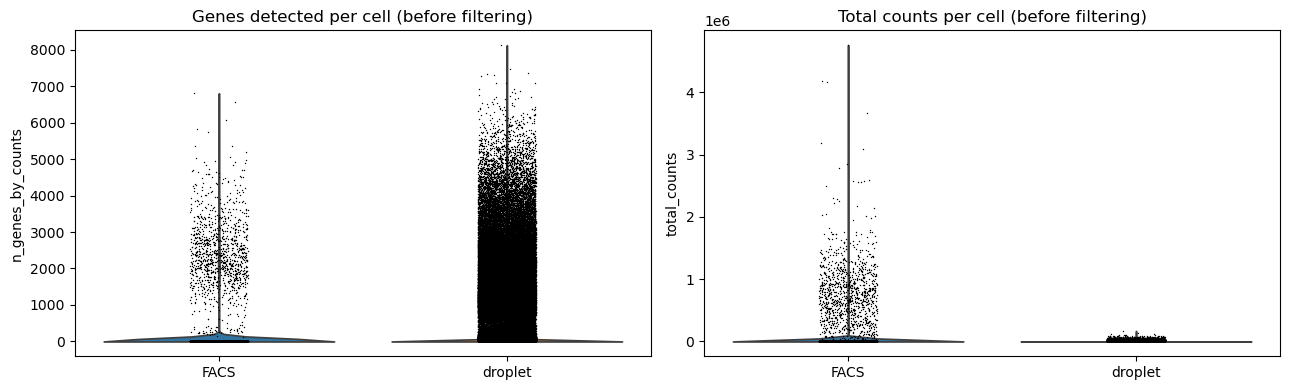

Before filtering: 3,010,851 cells, 23,433 genes
After  filtering: 59,983 cells, 19,447 genes


In [9]:
sc.pp.calculate_qc_metrics(combined, percent_top=None, log1p=False, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sc.pl.violin(combined, 'n_genes_by_counts', groupby='platform', ax=axes[0], show=False, rotation=0)
sc.pl.violin(combined, 'total_counts',      groupby='platform', ax=axes[1], show=False, rotation=0)
axes[0].set_title('Genes detected per cell (before filtering)')
axes[1].set_title('Total counts per cell (before filtering)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'qc_before_filtering.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Before filtering: {combined.n_obs:,} cells, {combined.n_vars:,} genes')
sc.pp.filter_cells(combined, min_genes=MIN_GENES)
sc.pp.filter_genes(combined, min_cells=MIN_CELLS)
print(f'After  filtering: {combined.n_obs:,} cells, {combined.n_vars:,} genes')

## Step 7 — Normalize Total Counts and Log-Transform

**`normalize_total` (CP10K):** Scales each cell so its total count sums to 10,000. This removes sequencing-depth differences between cells without changing relative gene expression.

**`log1p`:** Applies log(x + 1) to compress the dynamic range of expression values and stabilize variance — both of which benefit downstream PCA.

After log-transformation we store the current state in `adata.raw`. This preserves log-normalized counts for **all genes** (before HVG subsetting and scaling), which can be used later for visualization or differential expression.

In [10]:
sc.pp.normalize_total(combined, target_sum=1e4)
print('normalize_total: each cell scaled to 10,000 total counts.')

sc.pp.log1p(combined)
print('log1p: log(x+1) transformation applied.')

combined.raw = combined   # freeze log-normalized, unscaled full-gene matrix
print('adata.raw saved: log-normalized counts for all genes preserved.')

normalize_total: each cell scaled to 10,000 total counts.
log1p: log(x+1) transformation applied.
adata.raw saved: log-normalized counts for all genes preserved.


## Step 8 — Highly Variable Gene (HVG) Selection

We select the top `N_HVG = 2000` highly variable genes using the **Seurat dispersion method**.

`batch_key='platform'` computes HVG scores within each platform separately, then combines them. This prevents platform-specific technical variance from inflating gene variability scores and biasing feature selection toward batch-driven genes.

Subsetting to HVGs reduces noise, computation time, and memory while retaining the genes most informative for distinguishing cell types.

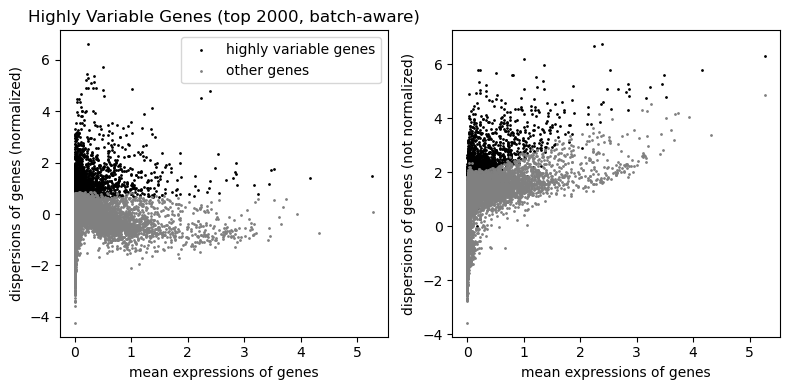

HVGs selected: 2000 / 19447
AnnData after HVG subsetting: (59983, 2000)


In [11]:
sc.pp.highly_variable_genes(combined, n_top_genes=N_HVG, batch_key='platform', flavor='seurat')

# Handle Scanpy versions that may or may not support ax= in this plotting function.
fig, ax = plt.subplots(figsize=(8, 4))
try:
    sc.pl.highly_variable_genes(combined, ax=ax, show=False)
except TypeError:
    plt.close(fig)
    sc.pl.highly_variable_genes(combined, show=False)
    fig = plt.gcf()
    ax = fig.axes[0] if fig.axes else None

if ax is not None:
    ax.set_title(f'Highly Variable Genes (top {N_HVG}, batch-aware)')
fig.set_size_inches(8, 4)
plt.tight_layout()
fig.savefig(OUT_DIR / 'figures' / 'hvg_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'HVGs selected: {combined.var["highly_variable"].sum()} / {combined.n_vars}')
combined = combined[:, combined.var['highly_variable']].copy()
print(f'AnnData after HVG subsetting: {combined.shape}')

## Step 9 — Scale Expression Values

**`sc.pp.scale`** centers each gene to zero mean and scales it to unit variance (z-score), clipped at `max_value=10`.

Scaling is applied *after* log-normalization and HVG selection so that PCA is driven by variance structure across cells rather than by genes with high absolute expression. The `max_value=10` clip limits the leverage of extreme outlier expression values.

In [12]:
sc.pp.scale(combined, max_value=10)
print('scale: genes centered to zero mean, scaled to unit variance, clipped at 10.')
print(f'X range after scaling: [{combined.X.min():.2f}, {combined.X.max():.2f}]')

scale: genes centered to zero mean, scaled to unit variance, clipped at 10.
X range after scaling: [-1.40, 10.00]


## Step 10 — Principal Component Analysis (PCA)

PCA compresses the 2000-gene scaled matrix into `N_PCS = 50` principal components. This low-dimensional embedding is the shared input for all three downstream pipelines.

The elbow plot (variance explained per component) helps verify that 50 PCs capture the bulk of informative variance.

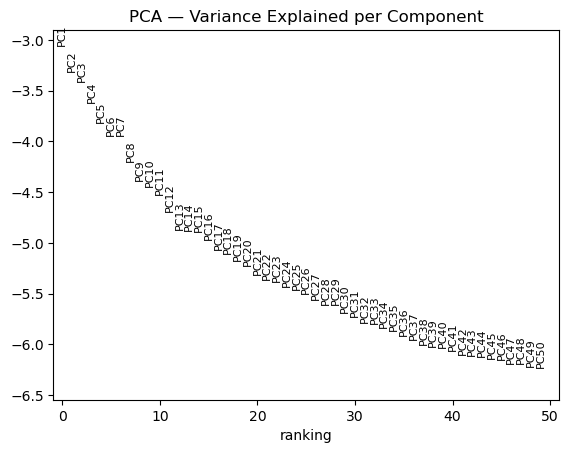

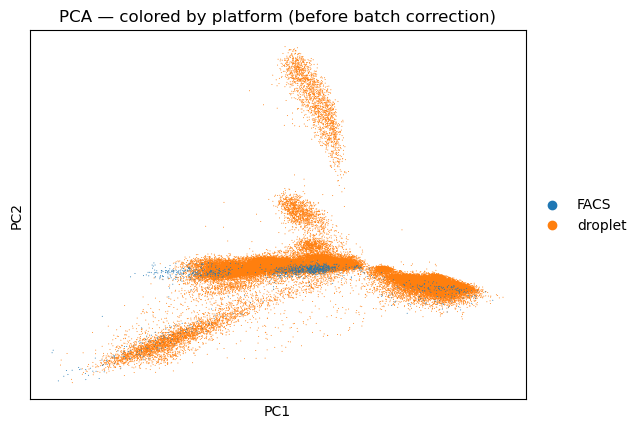

... storing 'subsetA' as categorical
... storing 'subsetB' as categorical
... storing 'subsetC' as categorical
... storing 'subsetD' as categorical


Converted obs['subsetA'] to string for H5AD compatibility.
Converted obs['subsetB'] to string for H5AD compatibility.
Converted obs['subsetC'] to string for H5AD compatibility.
Converted obs['subsetD'] to string for H5AD compatibility.
PCA complete: 50 components computed.


In [13]:
n_pcs_eff = min(N_PCS, combined.n_obs - 1, combined.n_vars - 1)
if n_pcs_eff < N_PCS:
    print(f'Warning: requested {N_PCS} PCs but data shape limits to {n_pcs_eff}')

sc.pp.pca(combined, n_comps=n_pcs_eff, svd_solver='arpack', random_state=SEED)

# Elbow plot — show=False keeps the figure open so plt.savefig targets the right figure
sc.pl.pca_variance_ratio(combined, n_pcs=n_pcs_eff, log=True, show=False)
plt.title('PCA — Variance Explained per Component')
plt.savefig(OUT_DIR / 'figures' / 'pca_variance_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

# PCA scatter coloured by platform
sc.pl.pca(combined, color='platform',
          title='PCA — colored by platform (before batch correction)',
          show=False)
plt.savefig(OUT_DIR / 'figures' / 'pca_by_platform.png', dpi=150, bbox_inches='tight')
plt.show()

# H5AD writing requires object-typed obs columns to contain strings only.
for col in combined.obs.select_dtypes(include='object').columns:
    non_null = combined.obs[col].dropna()
    if not non_null.map(lambda x: isinstance(x, str)).all():
        combined.obs[col] = combined.obs[col].astype(str)
        print(f"Converted obs['{col}'] to string for H5AD compatibility.")

print(f'PCA complete: {n_pcs_eff} components computed.')
combined.write_h5ad(OUT_DIR / 'adata' / 'combined_preprocessed.h5ad', compression='gzip')

---
## Pipeline A — Baseline: No Batch Correction + Leiden

A standard workflow applied directly to PCA coordinates without any batch correction:

1. **`neighbors`** — build a k-nearest-neighbor (kNN) graph from `X_pca`
2. **`umap`** — 2-D embedding for visualization
3. **`leiden`** — community detection at each resolution in `RESOLUTIONS`

This serves as the **uncorrected baseline** against which Harmony and BBKNN are compared.

In [14]:
baseline = combined.copy()

# kNN graph on raw PCA embedding
sc.pp.neighbors(baseline, n_neighbors=N_NEIGHBORS, use_rep='X_pca', random_state=SEED)

# UMAP for visualization
sc.tl.umap(baseline, random_state=SEED)

# Leiden clustering at each resolution
for res in RESOLUTIONS:
    key = f'leiden_r{str(res).replace(".", "_")}'
    sc.tl.leiden(baseline, resolution=res, key_added=key, random_state=SEED)
    n_clusters = baseline.obs[key].nunique()
    print(f'  Baseline resolution={res}: {n_clusters} clusters')

print('Pipeline A (baseline) complete.')
baseline.write_h5ad(OUT_DIR / 'adata' / 'pipeline_baseline_leiden.h5ad', compression='gzip')

KeyboardInterrupt: 

---
## Pipeline B — Harmony Batch Correction + Leiden

**Harmony** iteratively adjusts PCA embeddings to align cells across batches (here: platforms) while minimizing distortion of within-batch biological structure. The corrected embedding `X_pca_harmony` is then used to build the neighbor graph in place of the raw `X_pca`.

> **Implementation note:** `harmonypy` stores the corrected embedding as `Z_corr` with shape `(n_pcs, n_cells)`. We transpose it to `(n_cells, n_pcs)` before assigning to `obsm`, which is what Scanpy expects.

In [ ]:
harmony_adata = combined.copy()

# Harmony batch correction on the PCA embedding
harmony_meta = harmony_adata.obs[['platform']].copy().astype(str).fillna('unknown')
nclust = max(2, int(min(round(harmony_adata.n_obs / 30.0), 100)))

ho = hm.run_harmony(
    harmony_adata.obsm['X_pca'],
    harmony_meta,
    vars_use='platform',
    random_state=SEED,
    nclust=nclust,
)

# Harmonypy can return Z_corr in different containers/orientations across versions.
z_corr = ho.Z_corr
if hasattr(z_corr, 'to_numpy'):
    z_corr = z_corr.to_numpy()
z_corr = np.asarray(z_corr)

if z_corr.ndim == 1:
    # Common edge case: object array of per-PC vectors -> stack to 2D.
    z_corr = np.vstack(z_corr)

if z_corr.shape[0] == harmony_adata.n_obs:
    x_pca_harmony = z_corr
elif z_corr.shape[1] == harmony_adata.n_obs:
    x_pca_harmony = z_corr.T
else:
    raise ValueError(
        f'Unexpected Harmony output shape {z_corr.shape} for n_obs={harmony_adata.n_obs}'
    )

harmony_adata.obsm['X_pca_harmony'] = x_pca_harmony
print(f'Harmony corrected embedding shape: {harmony_adata.obsm["X_pca_harmony"].shape}')

# kNN graph on Harmony-corrected embedding
sc.pp.neighbors(harmony_adata, n_neighbors=N_NEIGHBORS, use_rep='X_pca_harmony', random_state=SEED)

# UMAP
sc.tl.umap(harmony_adata, random_state=SEED)

# Leiden clustering
for res in RESOLUTIONS:
    key = f'leiden_r{str(res).replace(".", "_")}'
    sc.tl.leiden(harmony_adata, resolution=res, key_added=key, random_state=SEED)
    n_clusters = harmony_adata.obs[key].nunique()
    print(f'  Harmony resolution={res}: {n_clusters} clusters')

print('Pipeline B (Harmony) complete.')
harmony_adata.write_h5ad(OUT_DIR / 'adata' / 'pipeline_harmony_leiden.h5ad', compression='gzip')

2026-04-27 00:36:36,009 - harmonypy - INFO - Running Harmony (PyTorch on mps)
[00:36:36] Running Harmony (PyTorch on mps)
2026-04-27 00:36:36,018 - harmonypy - INFO -   Parameters:
[00:36:36]   Parameters:
2026-04-27 00:36:36,024 - harmonypy - INFO -     max_iter_harmony: 10
[00:36:36]     max_iter_harmony: 10
2026-04-27 00:36:36,025 - harmonypy - INFO -     max_iter_kmeans: 20
[00:36:36]     max_iter_kmeans: 20
2026-04-27 00:36:36,027 - harmonypy - INFO -     epsilon_cluster: 1e-05
[00:36:36]     epsilon_cluster: 1e-05
2026-04-27 00:36:36,027 - harmonypy - INFO -     epsilon_harmony: 0.0001
[00:36:36]     epsilon_harmony: 0.0001
2026-04-27 00:36:36,028 - harmonypy - INFO -     nclust: 100
[00:36:36]     nclust: 100
2026-04-27 00:36:36,028 - harmonypy - INFO -     block_size: 0.05
[00:36:36]     block_size: 0.05
2026-04-27 00:36:36,034 - harmonypy - INFO -     lamb: [1. 1.]
[00:36:36]     lamb: [1. 1.]
2026-04-27 00:36:36,035 - harmonypy - INFO -     theta: [2. 2.]
[00:36:36]     theta

Harmony corrected embedding shape: (59983, 50)
  Harmony resolution=0.2: 34 clusters
  Harmony resolution=0.5: 47 clusters
  Harmony resolution=1.0: 57 clusters
  Harmony resolution=1.5: 69 clusters
Pipeline B (Harmony) complete.


---
## Pipeline C — BBKNN Batch Correction + Leiden

**BBKNN** (Batch-Balanced kNN) corrects for batch effects at the **graph level**: instead of a standard kNN, it finds neighbors within each batch separately and merges them. No embedding adjustment step is required — the correction is baked into the connectivity graph itself.

In [ ]:
bbknn_adata = combined.copy()

# BBKNN builds a batch-balanced neighbor graph directly
bbknn.bbknn(bbknn_adata, batch_key='platform', use_rep='X_pca', n_pcs=n_pcs_eff)

# UMAP
sc.tl.umap(bbknn_adata, random_state=SEED)

# Leiden clustering
for res in RESOLUTIONS:
    key = f'leiden_r{str(res).replace(".", "_")}'
    sc.tl.leiden(bbknn_adata, resolution=res, key_added=key, random_state=SEED)
    n_clusters = bbknn_adata.obs[key].nunique()
    print(f'  BBKNN resolution={res}: {n_clusters} clusters')

print('Pipeline C (BBKNN) complete.')
bbknn_adata.write_h5ad(OUT_DIR / 'adata' / 'pipeline_bbknn_leiden.h5ad', compression='gzip')

KeyboardInterrupt: 

---
## Evaluation — ARI, NMI, and Rare-Cell Recovery Rate

We define two types of metrics:

**Clustering quality (vs. expert labels):**
- **ARI** (Adjusted Rand Index) — agreement between cluster assignments and `cell_ontology_class` labels, adjusted for chance
- **NMI** (Normalized Mutual Information) — mutual information between cluster assignments and labels, normalized to [0, 1]

**Rare-cell recovery:**
For each tissue, a cell type is *rare* if it makes up fewer than `threshold`% of that tissue's cells. A rare type is *recovered* if there exists at least one cluster where ≥ 50% of the cluster's cells are of that rare type (purity ≥ 0.5). We report the fraction of rare types recovered.

In [ ]:
def compute_ari_nmi(obs: pd.DataFrame, cluster_col: str, label_col: str = 'cell_ontology_class'):
    valid = obs[label_col].notna() & obs[cluster_col].notna()
    if valid.sum() == 0:
        return np.nan, np.nan
    y_true = obs.loc[valid, label_col].astype(str)
    y_pred = obs.loc[valid, cluster_col].astype(str)
    return adjusted_rand_score(y_true, y_pred), normalized_mutual_info_score(y_true, y_pred)


def rare_recovery(
    obs: pd.DataFrame,
    cluster_col: str,
    threshold_pct: float,
    purity_cutoff: float = PURITY_CUTOFF,
    label_col: str = 'cell_ontology_class',
    tissue_col: str = 'tissue',
) -> Dict:
    df = obs[[label_col, tissue_col, cluster_col]].dropna()
    if df.empty:
        return {'n_rare': 0.0, 'n_recovered': 0.0, 'rate': np.nan}

    threshold = threshold_pct / 100.0
    rare_total = recovered_total = 0

    for tissue, tdf in df.groupby(tissue_col, observed=False):
        label_freq = tdf[label_col].value_counts(normalize=True)
        rare_labels = label_freq[label_freq < threshold].index.tolist()
        for label in rare_labels:
            rare_total += 1
            rare_cells = tdf[tdf[label_col] == label]
            for cluster_name, count in rare_cells[cluster_col].value_counts().items():
                cluster_size = df[df[cluster_col] == cluster_name].shape[0]
                if cluster_size and (count / cluster_size) >= purity_cutoff:
                    recovered_total += 1
                    break

    rate = recovered_total / rare_total if rare_total else np.nan
    return {'n_rare': float(rare_total), 'n_recovered': float(recovered_total), 'rate': rate}


def evaluate_pipeline(name: str, adata: ad.AnnData) -> pd.DataFrame:
    rows = []
    for res in RESOLUTIONS:
        cluster_col = f'leiden_r{str(res).replace(".", "_")}'
        ari, nmi = compute_ari_nmi(adata.obs, cluster_col)
        row = {'pipeline': name, 'resolution': res, 'n_cells': adata.n_obs, 'ari': ari, 'nmi': nmi}
        for thr in RARE_THRESHOLDS:
            stats = rare_recovery(adata.obs, cluster_col, thr)
            col   = f'rare_recovery_lt{str(thr).replace(".", "_")}pct'
            row[col] = stats['rate']
            row[f'n_rare_lt{str(thr).replace(".", "_")}pct']      = stats['n_rare']
            row[f'n_recovered_lt{str(thr).replace(".", "_")}pct'] = stats['n_recovered']
        rows.append(row)
    return pd.DataFrame(rows)


print('Evaluation functions defined.')

Evaluation functions defined.


In [ ]:
metrics_df = pd.concat([
    evaluate_pipeline('baseline', baseline),
    evaluate_pipeline('harmony',  harmony_adata),
    evaluate_pipeline('bbknn',    bbknn_adata),
], ignore_index=True)

metrics_df.to_csv(OUT_DIR / 'metrics' / 'metrics_by_pipeline_resolution.csv', index=False)

summary_cols = ['pipeline', 'resolution', 'ari', 'nmi'] + \
               [f'rare_recovery_lt{str(t).replace(".", "_")}pct' for t in RARE_THRESHOLDS]
summary_df = metrics_df[summary_cols].copy()
summary_df.to_csv(OUT_DIR / 'metrics' / 'metrics_summary.csv', index=False)

print('Metrics computed and saved.')
summary_df.round(3)

Metrics computed and saved.


,pipeline,resolution,ari,nmi,rare_recovery_lt0_5pct,rare_recovery_lt1_0pct,rare_recovery_lt2_0pct
0,baseline,0.2,0.751,0.849,0.000,0.000,0.002
1,baseline,0.5,0.715,0.842,0.000,0.002,0.004
2,baseline,1.0,0.629,0.829,0.000,0.002,0.006
3,baseline,1.5,0.500,0.812,0.000,0.002,0.004
4,harmony,0.2,0.716,0.834,0.000,0.000,0.002
5,harmony,0.5,0.692,0.837,0.000,0.002,0.006
6,harmony,1.0,0.648,0.831,0.000,0.002,0.006
7,harmony,1.5,0.495,0.805,0.000,0.002,0.004
8,bbknn,0.2,0.006,0.048,0.000,0.000,0.000
9,bbknn,0.5,0.006,0.048,0.000,0.000,0.000


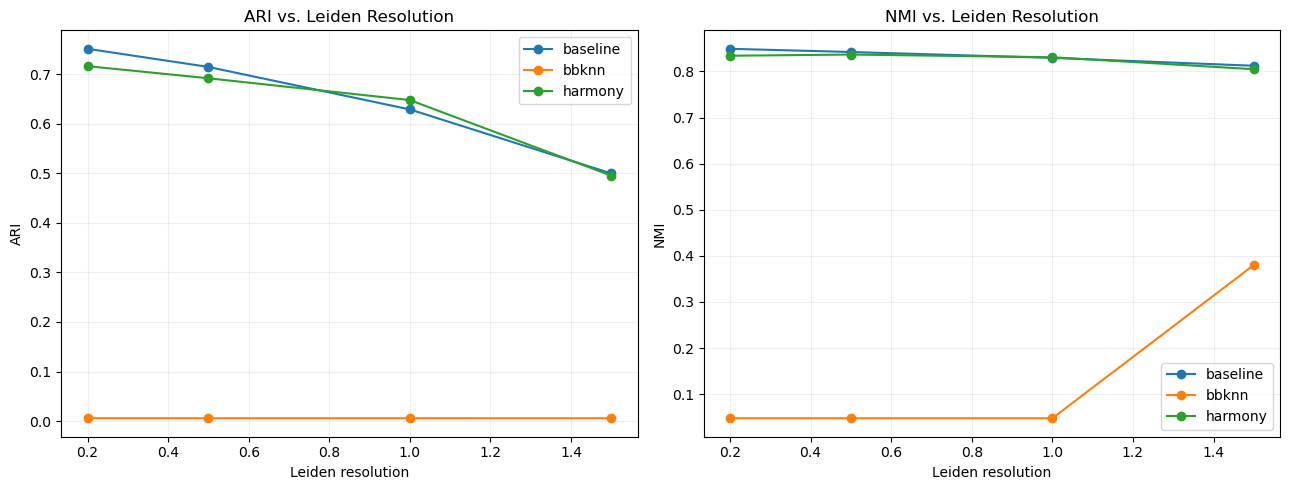

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for pipeline_name, part in metrics_df.groupby('pipeline'):
    part = part.sort_values('resolution')
    axes[0].plot(part['resolution'], part['ari'], marker='o', label=pipeline_name)
    axes[1].plot(part['resolution'], part['nmi'], marker='o', label=pipeline_name)

for ax, metric in zip(axes, ['ARI', 'NMI']):
    ax.set_title(f'{metric} vs. Leiden Resolution')
    ax.set_xlabel('Leiden resolution')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(OUT_DIR / 'figures' / 'ari_nmi_by_resolution.png', dpi=150, bbox_inches='tight')
plt.show()

## Rare-Cell Recovery Rate Across Resolutions

For each rare-cell threshold (0.5%, 1%, 2%) we plot recovery rate vs. Leiden resolution for all three pipelines. A higher curve indicates better preservation of rare populations at that resolution.

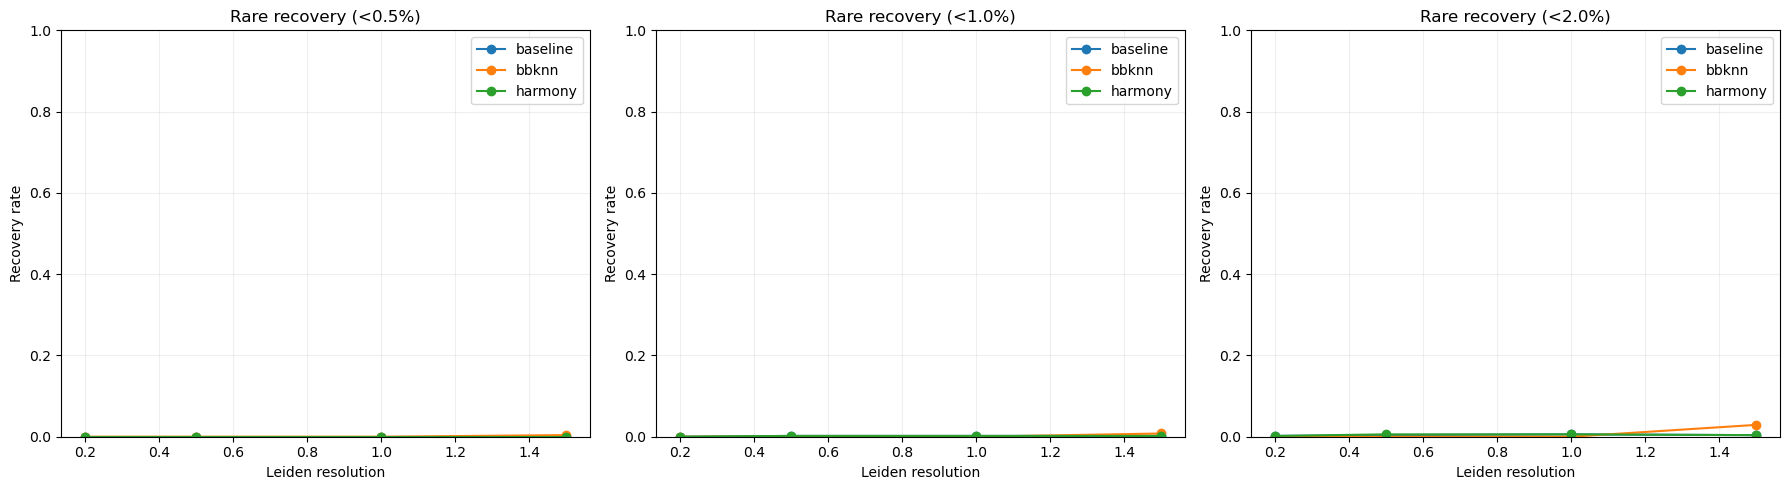

In [ ]:
def set_zoomed_ylim(ax, values, min_span=0.05, pad_frac=0.15):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return
    y_min, y_max = vals.min(), vals.max()
    span = max(y_max - y_min, min_span)
    pad = max(span * pad_frac, 0.01)
    lower = max(0.0, y_min - pad)
    upper = min(1.0, y_max + pad)
    if upper - lower < min_span:
        mid = 0.5 * (lower + upper)
        lower = max(0.0, mid - min_span / 2)
        upper = min(1.0, mid + min_span / 2)
    ax.set_ylim(lower, upper)

# Save one figure per threshold (individual files, matching the proposal)
for threshold in RARE_THRESHOLDS:
    col  = f'rare_recovery_lt{str(threshold).replace(".", "_")}pct'
    fig, ax = plt.subplots(figsize=(7, 5))
    for pipeline_name, part in metrics_df.groupby('pipeline'):
        part = part.sort_values('resolution')
        ax.plot(part['resolution'], part[col], marker='o', label=pipeline_name)
    ax.set_title(f'Rare-cell recovery (<{threshold}% per tissue)')
    ax.set_xlabel('Leiden resolution')
    ax.set_ylabel('Recovery rate')
    set_zoomed_ylim(ax, metrics_df[col].to_numpy())
    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()
    fname = f'rare_recovery_lt{str(threshold).replace(".", "_")}pct.png'
    fig.savefig(OUT_DIR / 'figures' / fname, dpi=150, bbox_inches='tight')
    plt.close(fig)

# Also display all thresholds in one combined panel for the notebook
fig, axes = plt.subplots(1, len(RARE_THRESHOLDS), figsize=(6 * len(RARE_THRESHOLDS), 5))
if len(RARE_THRESHOLDS) == 1:
    axes = [axes]

for ax, threshold in zip(axes, RARE_THRESHOLDS):
    col = f'rare_recovery_lt{str(threshold).replace(".", "_")}pct'
    for pipeline_name, part in metrics_df.groupby('pipeline'):
        part = part.sort_values('resolution')
        ax.plot(part['resolution'], part[col], marker='o', label=pipeline_name)
    ax.set_title(f'Rare recovery (<{threshold}%)')
    ax.set_xlabel('Leiden resolution')
    ax.set_ylabel('Recovery rate')
    set_zoomed_ylim(ax, metrics_df[col].to_numpy())
    ax.grid(alpha=0.2)
    ax.legend()

fig.tight_layout()
fig.savefig(OUT_DIR / 'figures' / 'rare_recovery_all_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## UMAP Visualizations

For each pipeline we generate a triplet of UMAPs colored by:
1. **Platform** — reveals how well batch effects are corrected
2. **Tissue** — shows tissue-level separation
3. **Cell type** (`cell_ontology_class`) — assesses biological clustering quality

These use the fixed resolution `FIXED_RES` for the Leiden overlay.

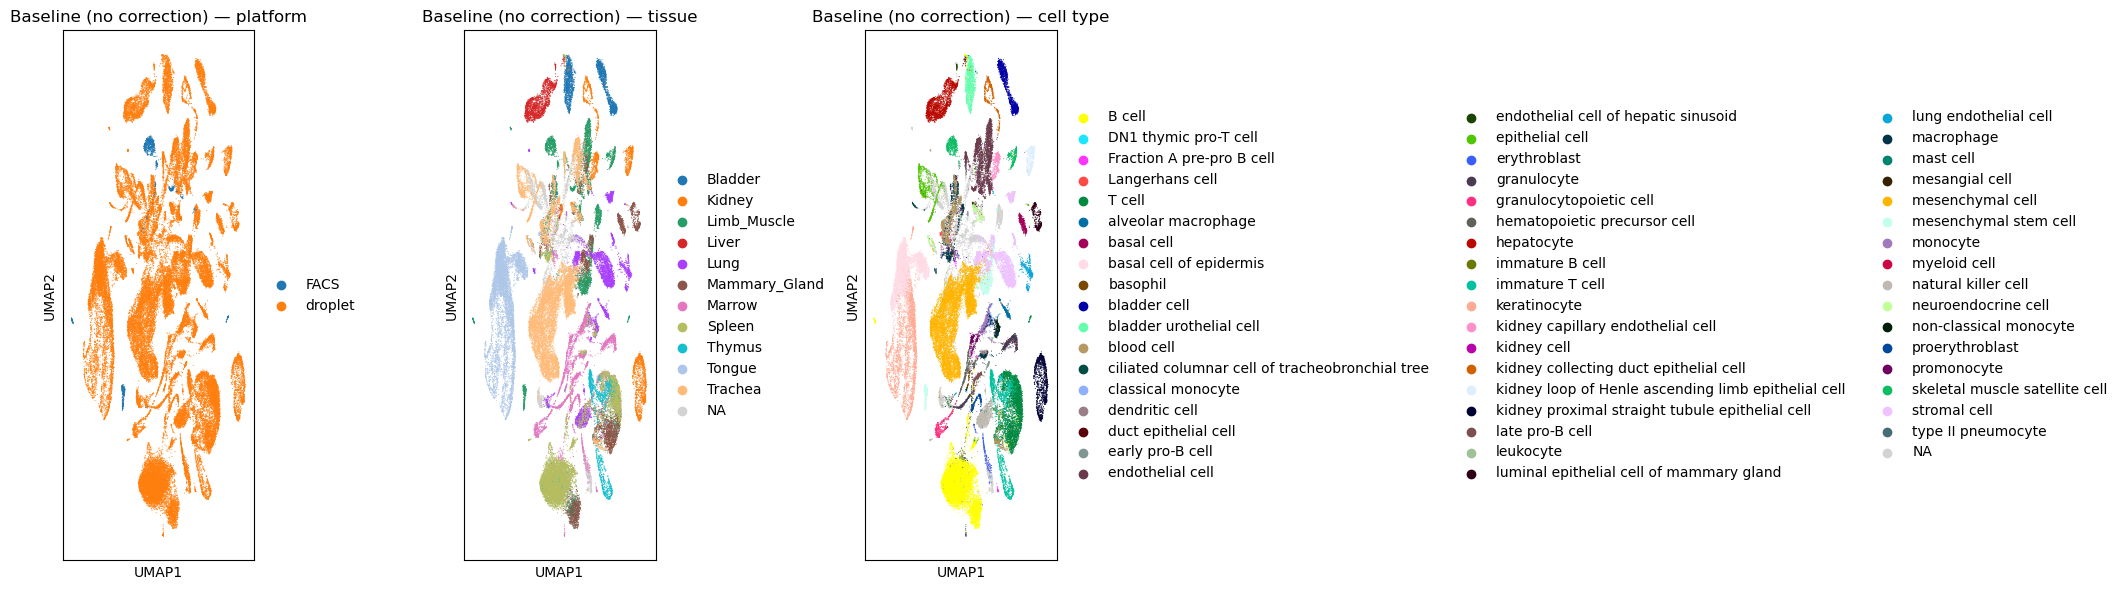

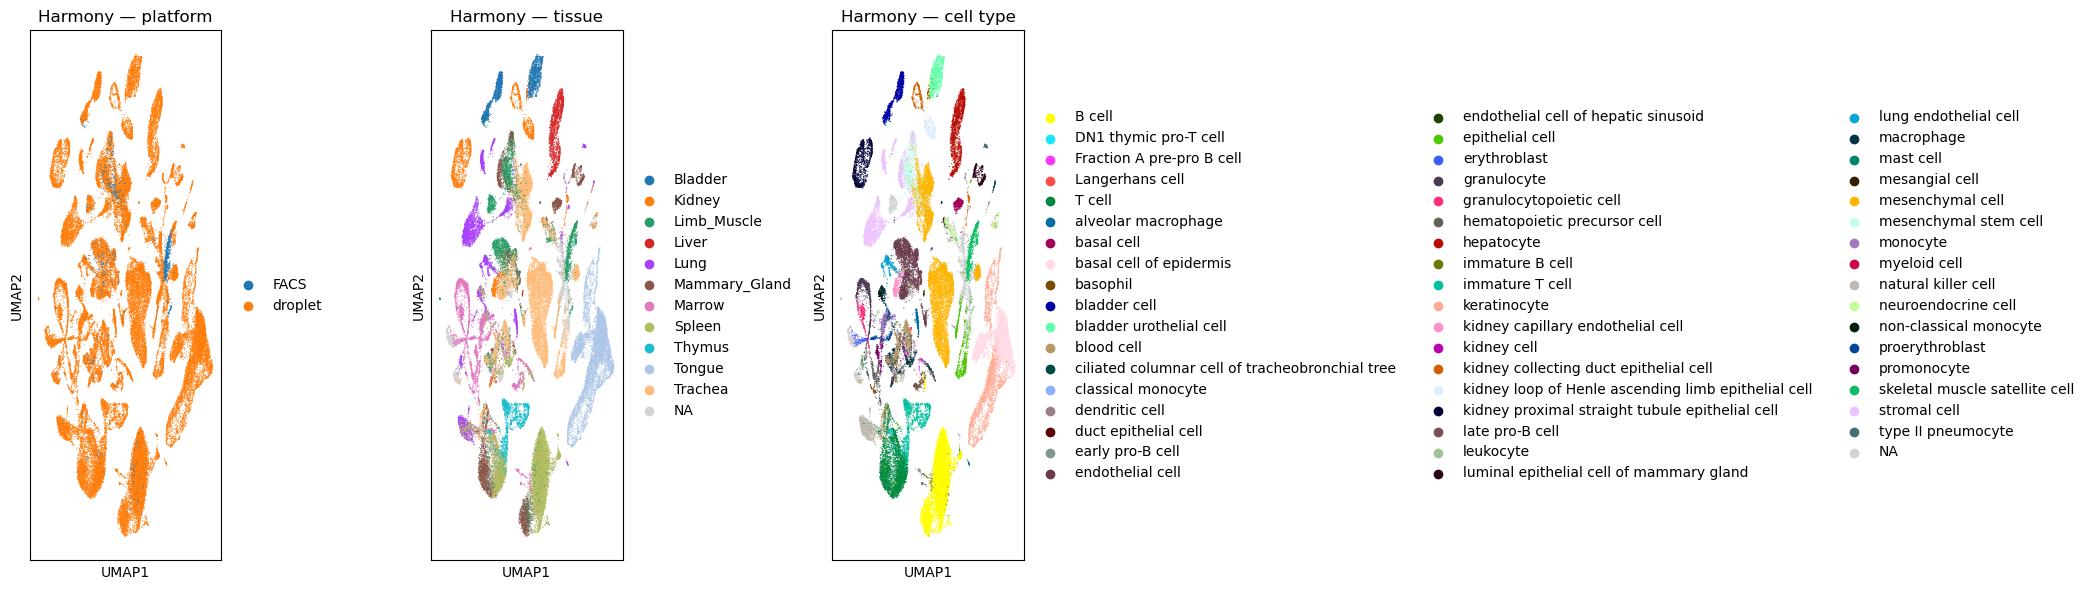

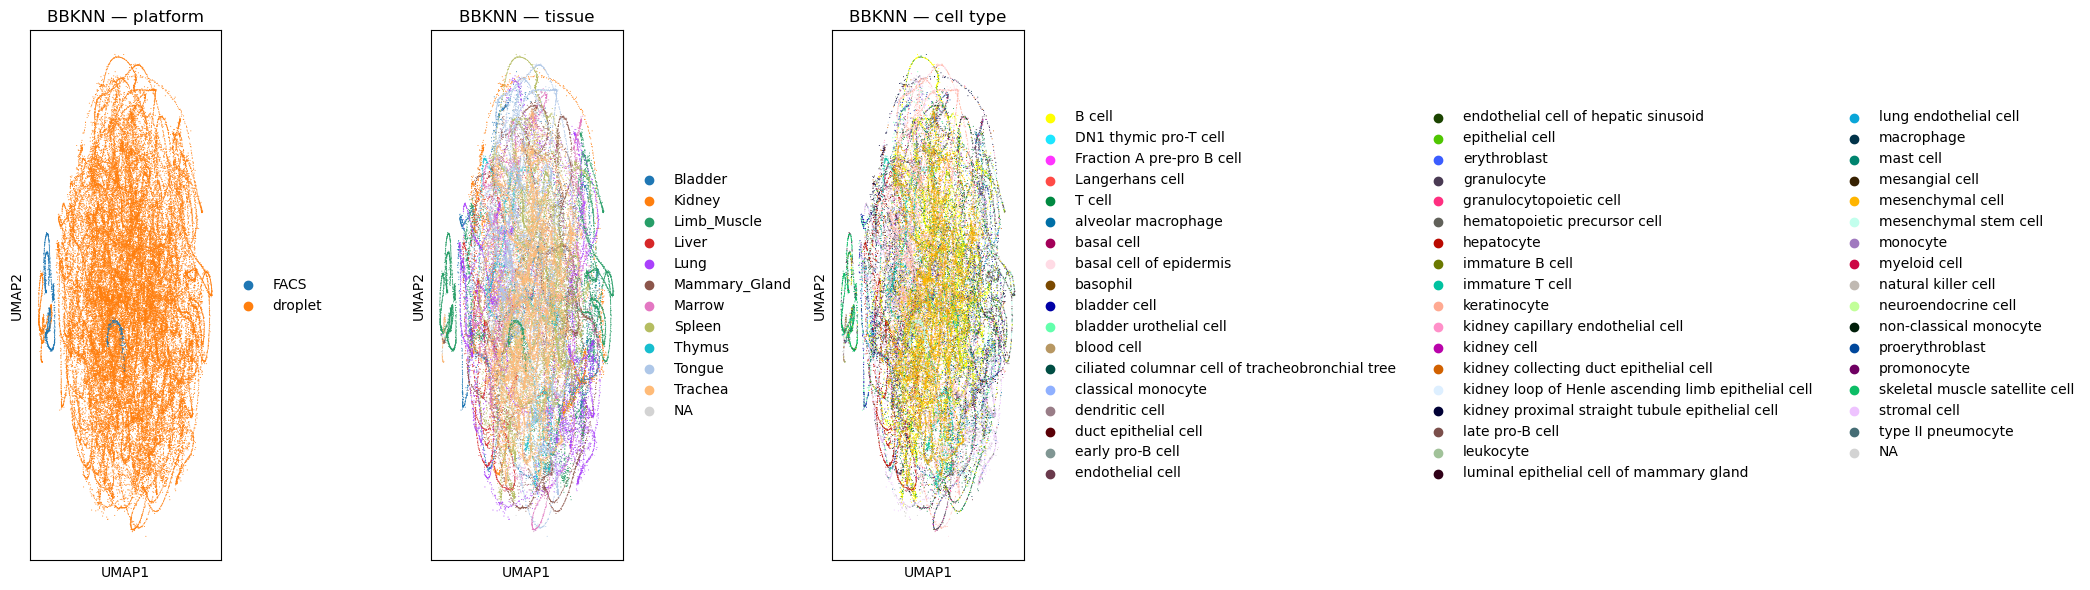

In [ ]:
def categorical_palette(adata: ad.AnnData, key: str):
    n_cats = adata.obs[key].astype('category').cat.categories.size
    if n_cats <= len(sc.pl.palettes.default_102):
        return sc.pl.palettes.default_102[:n_cats]
    # Fallback for very high-cardinality labels.
    return [plt.cm.gist_ncar(i / max(n_cats - 1, 1)) for i in range(n_cats)]

def plot_umap_triplet(adata: ad.AnnData, title_prefix: str, save_path: Path) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    sc.pl.umap(
        adata,
        color='platform',
        ax=axes[0],
        show=False,
        title=f'{title_prefix} — platform',
        palette=categorical_palette(adata, 'platform'),
    )
    sc.pl.umap(
        adata,
        color='tissue',
        ax=axes[1],
        show=False,
        title=f'{title_prefix} — tissue',
        palette=categorical_palette(adata, 'tissue'),
    )
    sc.pl.umap(
        adata,
        color='cell_ontology_class',
        ax=axes[2],
        show=False,
        title=f'{title_prefix} — cell type',
        legend_loc='right margin',
        palette=categorical_palette(adata, 'cell_ontology_class'),
    )
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_umap_triplet(baseline,      'Baseline (no correction)', OUT_DIR / 'figures' / 'baseline_umap_triplet.png')
plot_umap_triplet(harmony_adata, 'Harmony',                  OUT_DIR / 'figures' / 'harmony_umap_triplet.png')
plot_umap_triplet(bbknn_adata,   'BBKNN',                    OUT_DIR / 'figures' / 'bbknn_umap_triplet.png')

---
## Case Study — Immune Cells Across Tissues

Tabula Muris is particularly suited for studying immune cells because T cells and macrophages appear in multiple organs. We subset each pipeline's output to cells annotated as T cells or macrophages and examine whether they cluster by **cell type** (desired) or by **tissue / platform** (batch-driven).

For each pipeline we produce:
- A UMAP colored by cell type and tissue for the immune subset
- A summary table of cluster composition by cell type, tissue, and platform

[baseline] Immune subset: 7,576 cells
cell_ontology_class
T cell                   4444
macrophage               1365
immature T cell          1354
alveolar macrophage       345
DN1 thymic pro-T cell      44
mast cell                  24


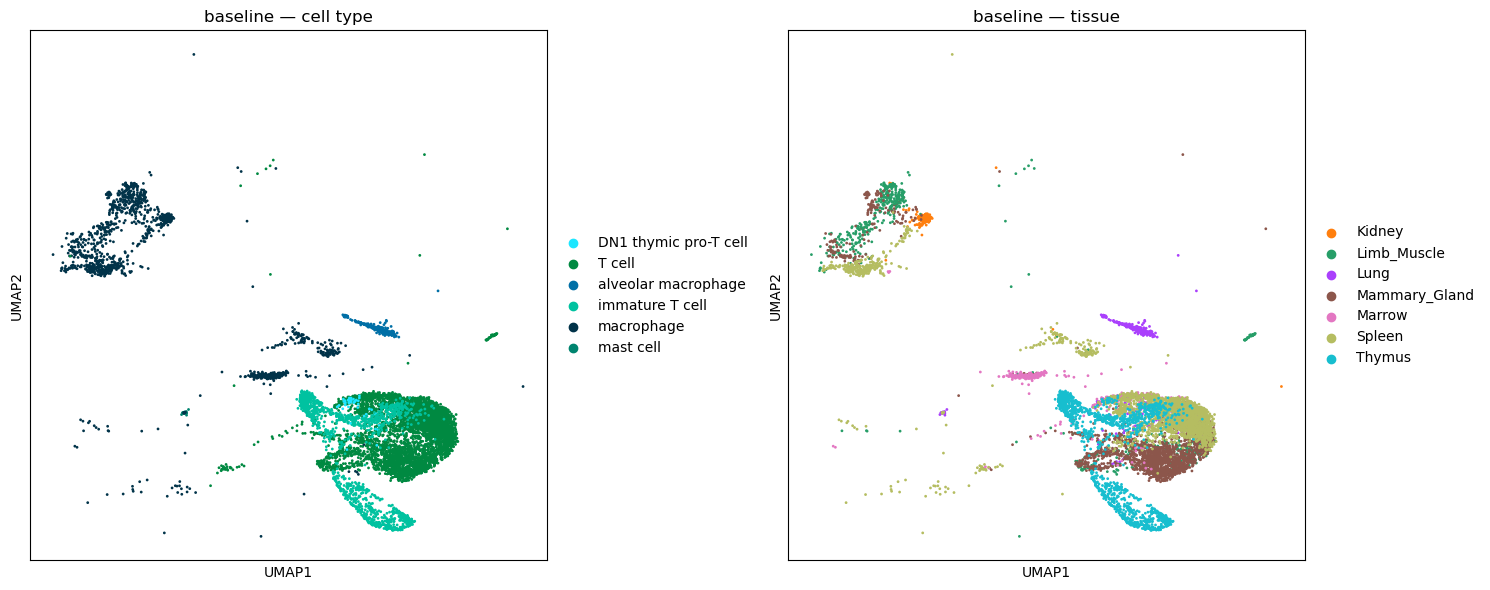

[baseline] Cluster table saved.

[harmony] Immune subset: 7,576 cells
cell_ontology_class
T cell                   4444
macrophage               1365
immature T cell          1354
alveolar macrophage       345
DN1 thymic pro-T cell      44
mast cell                  24


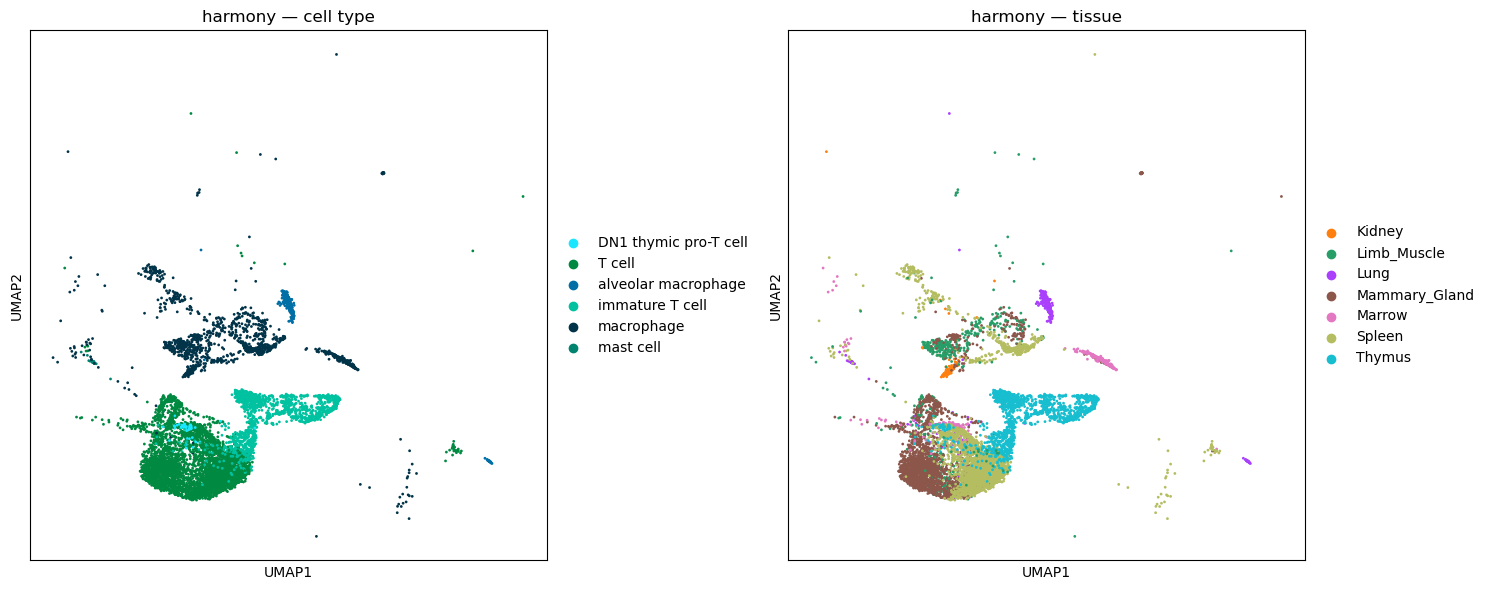

[harmony] Cluster table saved.

[bbknn] Immune subset: 7,576 cells
cell_ontology_class
T cell                   4444
macrophage               1365
immature T cell          1354
alveolar macrophage       345
DN1 thymic pro-T cell      44
mast cell                  24


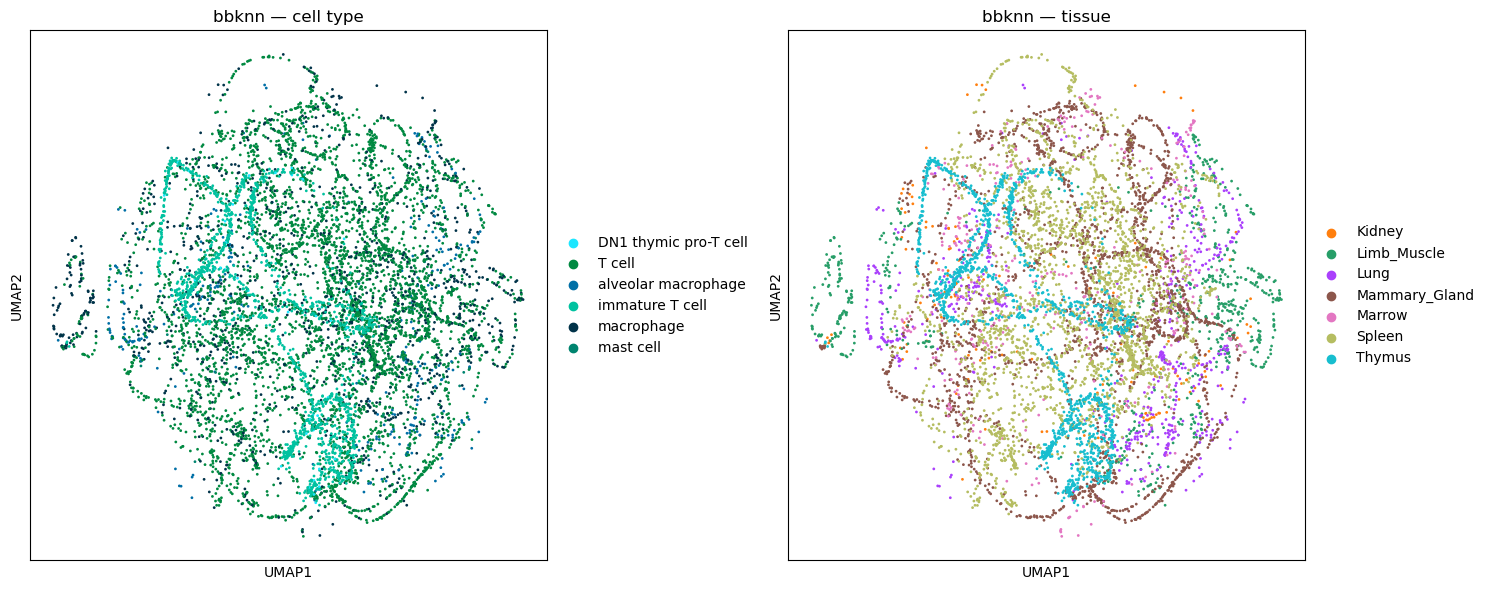

[bbknn] Cluster table saved.



In [ ]:
def immune_case_study(adata: ad.AnnData, pipeline_name: str) -> None:
    cluster_col = f'leiden_r{str(FIXED_RES).replace(".", "_")}'
    labels      = adata.obs['cell_ontology_class'].astype(str)
    immune_mask = labels.str.contains('T cell|macrophage', case=False, na=False)

    if immune_mask.sum() == 0:
        print(f'[{pipeline_name}] No T cells or macrophages found — skipping case study.')
        return

    immune = adata[immune_mask].copy()
    print(f'[{pipeline_name}] Immune subset: {immune.n_obs:,} cells')
    print(immune.obs['cell_ontology_class'].value_counts().head(10).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sc.pl.umap(
        immune,
        color='cell_ontology_class',
        ax=axes[0],
        show=False,
        title=f'{pipeline_name} — cell type',
        legend_loc='right margin',
        palette=categorical_palette(immune, 'cell_ontology_class'),
    )
    sc.pl.umap(
        immune,
        color='tissue',
        ax=axes[1],
        show=False,
        title=f'{pipeline_name} — tissue',
        legend_loc='right margin',
        palette=categorical_palette(immune, 'tissue'),
    )
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'figures' / f'{pipeline_name}_immune_umap.png', dpi=150, bbox_inches='tight')
    plt.show()

    table = (
        immune.obs
        .groupby(['cell_ontology_class', 'platform', 'tissue', cluster_col], observed=False)
        .size()
        .reset_index(name='n_cells')
    )
    table.to_csv(OUT_DIR / 'figures' / f'{pipeline_name}_immune_cluster_table.csv', index=False)
    print(f'[{pipeline_name}] Cluster table saved.\n')


immune_case_study(baseline,      'baseline')
immune_case_study(harmony_adata, 'harmony')
immune_case_study(bbknn_adata,   'bbknn')

---
## Summary

All outputs have been written to `outputs/`:

| Path | Content |
|---|---|
| `adata/combined_preprocessed.h5ad` | Preprocessed combined AnnData (HVG, scaled, PCA) |
| `adata/pipeline_baseline_leiden.h5ad` | Baseline pipeline with UMAP + Leiden |
| `adata/pipeline_harmony_leiden.h5ad` | Harmony pipeline with UMAP + Leiden |
| `adata/pipeline_bbknn_leiden.h5ad` | BBKNN pipeline with UMAP + Leiden |
| `metrics/metrics_by_pipeline_resolution.csv` | Full metrics table |
| `metrics/metrics_summary.csv` | ARI, NMI, rare recovery summary |
| `figures/` | All UMAP plots, QC plots, HVG plot, recovery curves |

In [ ]:
print('=== Final Metrics Summary ===')
print(summary_df.round(3).to_string(index=False))

=== Final Metrics Summary ===
pipeline  resolution   ari   nmi  rare_recovery_lt0_5pct  rare_recovery_lt1_0pct  rare_recovery_lt2_0pct
baseline         0.2 0.751 0.849                   0.000                   0.000                   0.002
baseline         0.5 0.715 0.842                   0.000                   0.002                   0.004
baseline         1.0 0.629 0.829                   0.000                   0.002                   0.006
baseline         1.5 0.500 0.812                   0.000                   0.002                   0.004
 harmony         0.2 0.716 0.834                   0.000                   0.000                   0.002
 harmony         0.5 0.692 0.837                   0.000                   0.002                   0.006
 harmony         1.0 0.648 0.831                   0.000                   0.002                   0.006
 harmony         1.5 0.495 0.805                   0.000                   0.002                   0.004
   bbknn         0.2 0.00